# 05 -- Final Suspect List + Formal Evaluation vs. Answer Set

Combines Layer 1 + Layer 2 output into a tiered suspect list, then evaluates against
the CERT r6.2 Answer Set (6 accounts, `src/awik/config.py`) -- the only notebook
where the Answer Set is used for anything beyond reporting. Includes the R2-4
per-account audit table and R2-6 precision/FPR/PR-AUC responses.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

from awik.config import ANSWER_SET, MALICIOUS_USERS
from awik.evaluation import evaluate_against_answerset, enrichment, enrichment_pvalue
from awik import io

df_master = io.load_df('01_df_master')
state03 = io.load_json('03_layer1_state')
l1_flagged = set(state03['l1_flagged'])
df_ranking = io.load_df('03_df_ranking')
df_surges = io.load_df('04_df_surges')

state04 = io.load_json('04_layer2_state')
users_targeted = set(state04['users_targeted'])
graph_confirmed = set(state04['graph_confirmed'])
g1_suspects = set(state04['g1_suspects']); g2_suspects = set(state04['g2_suspects'])
g3_suspects = set(state04['g3_suspects']); g5_suspects = set(state04['g5_suspects'])
g6_suspects = set(state04['g6_suspects'])
candidates_graph = state04['candidates_graph']; near_miss_group = state04['near_miss_group']
graph_confirmed_ablasi = set(state04['graph_confirmed_ablasi'])
candidates_graph_ablasi = state04['candidates_graph_ablasi']

## Final suspect list + priority tier

In [2]:
all_suspects = l1_flagged | graph_confirmed
tier_rows = []
for uid in all_suspects:
    in_l1, in_bl, in_graph = uid in l1_flagged, uid in users_targeted, uid in graph_confirmed
    n_sig = sum([in_l1, in_bl, in_graph])
    if n_sig == 3:
        tier = 'TIER-1: Spatial+Baseline+Graph'
    elif in_l1 and in_graph:
        tier = 'TIER-2: Spatial+Graph'
    elif in_bl and in_graph and not in_l1:
        tier = 'TIER-2b: Baseline+Graph (Near-Miss)'
    elif in_l1 and in_bl:
        tier = 'TIER-3: Spatial+Baseline'
    elif in_l1:
        tier = 'TIER-4: Spatial Only'
    else:
        tier = 'TIER-5: Graph Only'

    rank = df_ranking.index[df_ranking['User_ID']==uid].tolist()
    score = df_ranking[df_ranking['User_ID']==uid]['AWIK_Score'].values[0] if rank else 0.0
    patterns = [g for g, s in [('G1',g1_suspects),('G2',g2_suspects),('G3',g3_suspects),
                                 ('G5',g5_suspects),('G6',g6_suspects)] if uid in s]
    tier_rows.append({
        'User_ID': uid, 'Tier': tier, 'AWIK_Score': round(score, 3),
        'L1_Spatial': 'YES' if in_l1 else 'NO', 'Baseline': 'YES' if in_bl else 'NO',
        'Graph_Patterns': '+'.join(patterns) if patterns else '-',
    })

df_final = pd.DataFrame(tier_rows).sort_values(['Tier','AWIK_Score'], ascending=[True, False]).reset_index(drop=True)
print(f"Total suspects: {len(df_final):,}")
for tier, count in df_final['Tier'].value_counts().sort_index().items():
    print(f"  {tier}: {count:,} users")
df_final.head(15)

Total suspects: 1,182
  TIER-1: Spatial+Baseline+Graph: 132 users
  TIER-2: Spatial+Graph: 42 users
  TIER-2b: Baseline+Graph (Near-Miss): 21 users
  TIER-4: Spatial Only: 882 users
  TIER-5: Graph Only: 105 users


,User_ID,Tier,AWIK_Score,L1_Spatial,Baseline,Graph_Patterns
0,UXC1495,TIER-1: Spatial+Baseline+Graph,50.752,YES,YES,G1+G2+G3
1,ETG2821,TIER-1: Spatial+Baseline+Graph,41.251,YES,YES,G1+G2+G3
2,AIJ3995,TIER-1: Spatial+Baseline+Graph,34.339,YES,YES,G1+G2+G3
3,MHG3749,TIER-1: Spatial+Baseline+Graph,31.317,YES,YES,G1+G2+G3+G6
4,CRP3682,TIER-1: Spatial+Baseline+Graph,31.158,YES,YES,G1+G2+G3
5,VAB1526,TIER-1: Spatial+Baseline+Graph,30.383,YES,YES,G1+G2+G3
6,ECB1683,TIER-1: Spatial+Baseline+Graph,29.445,YES,YES,G1+G2+G3+G6
7,BDJ3326,TIER-1: Spatial+Baseline+Graph,29.382,YES,YES,G1+G2+G3
8,BHE1709,TIER-1: Spatial+Baseline+Graph,28.727,YES,YES,G1+G2+G3+G6
9,JBB0847,TIER-1: Spatial+Baseline+Graph,28.287,YES,YES,G1+G2+G3+G6


## Formal evaluation vs. Answer Set (6 actors)

In [3]:
from scipy.stats import hypergeom

full_system = l1_flagged | graph_confirmed
h_l1 = evaluate_against_answerset(l1_flagged, MALICIOUS_USERS,
        'Layer 1: Magnitude (K-Means->DBSCAN->empirical Mahalanobis)')
h_gc = evaluate_against_answerset(graph_confirmed, MALICIOUS_USERS,
        'Layer 2: Graph-confirmed (G1,G2,G3,G5,G6)')
h_full = evaluate_against_answerset(full_system, MALICIOUS_USERS, 'Full System (L1 + Graph)')
df_eval = pd.DataFrame([h_l1, h_gc, h_full])[['Label','Recall','Precision','F1','TP','FN','FP']]
df_eval

,Label,Recall,Precision,F1,TP,FN,FP
0,Layer 1: Magnitude (K-Means->DBSCAN->empirical...,0.3333,0.001894,0.003766,2,4,1054
1,"Layer 2: Graph-confirmed (G1,G2,G3,G5,G6)",0.3333,0.006667,0.013072,2,4,298
2,Full System (L1 + Graph),0.6667,0.003384,0.006734,4,2,1178


CAPTURE PATH PER ACTOR:
  [1] ACM2278    | ATTACKER           | FALSE NEGATIVE
        L1: NO | baseline-surge: ah+usb | graph: NO
  [2] CMP2946    | ATTACKER           | CAUGHT
        L1: YES (Rank #956) | baseline-surge: ah+usb | graph: NO
  [3] PLJ1771    | ATTACKER           | CAUGHT
        L1: NO | baseline-surge: ah+usb+email | graph: G6
  [3] HIS1706    | HIJACKED_ACCOUNT   | FALSE NEGATIVE
        L1: NO | baseline-surge: ah | graph: NO
  [4] CDE1846    | ATTACKER           | CAUGHT
        L1: NO | baseline-surge: ah | graph: G6
  [5] MBG3183    | ATTACKER           | CAUGHT
        L1: YES (Rank #790) | baseline-surge: usb+email | graph: NO

System coverage (6 actors): 4/6 (Recall 0.6667)
Routing (users_targeted): 160/4000 population (4.00%) receives targeted graph inspection

ENRICHMENT vs. non-actors (hypergeometric p):
  Layer 1 magnitude         :  1056 users | TP 2/6 | enrich   1.3x | p=5.0e-01
  users_targeted (routing)  :   160 users | TP 1/6 | enrich   4.2x | p=2.2e

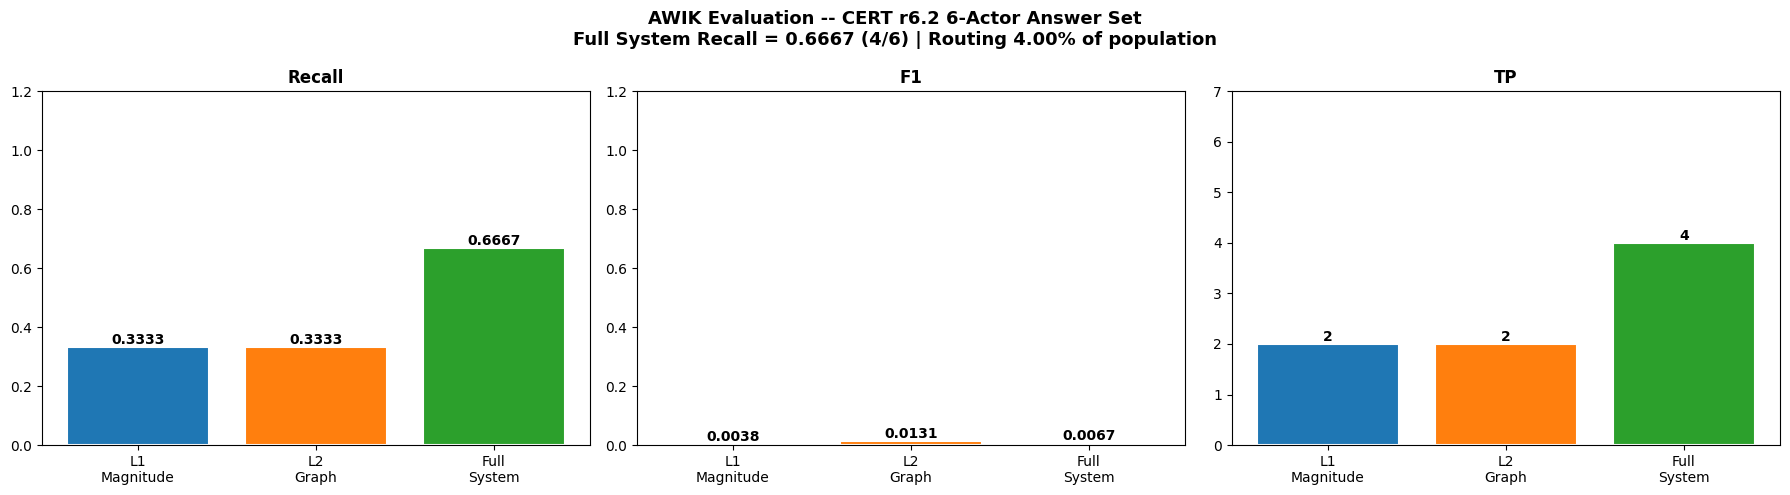

In [4]:
def surge_label(uid):
    if df_surges.empty: return '-'
    r = df_surges[df_surges['User_ID']==uid]
    if r.empty: return '-'
    return '+'.join([c.replace('lon_','') for c in ['lon_ah','lon_usb','lon_email'] if r[c].max()==1])

print("CAPTURE PATH PER ACTOR:")
for uid, info in ANSWER_SET.items():
    in_l1 = uid in l1_flagged
    g_found = [g for g,s in [('G1',g1_suspects),('G2',g2_suspects),('G3',g3_suspects),
               ('G5',g5_suspects),('G6',g6_suspects)] if uid in s]
    status = "CAUGHT" if uid in full_system else "FALSE NEGATIVE"
    rank = df_ranking.index[df_ranking['User_ID']==uid].tolist()
    rs = f"Rank #{rank[0]+1}" if rank else "not L1-flagged"
    print(f"  [{info['scenario']}] {uid:10s} | {info['role']:18s} | {status}")
    print(f"        L1: {'YES ('+rs+')' if in_l1 else 'NO'} | "
          f"baseline-surge: {surge_label(uid)} | graph: {'+'.join(g_found) or 'NO'}")

total_caught = len(set(MALICIOUS_USERS) & full_system)
pop = df_master['User_ID'].nunique(); n_actor = len(MALICIOUS_USERS)
print(f"\nSystem coverage (6 actors): {total_caught}/6 (Recall {total_caught/6:.4f})")
print(f"Routing (users_targeted): {len(users_targeted)}/{pop} population "
      f"({len(users_targeted)/pop*100:.2f}%) receives targeted graph inspection")

print("\nENRICHMENT vs. non-actors (hypergeometric p):")
for nama, S in [('Layer 1 magnitude', l1_flagged), ('users_targeted (routing)', users_targeted),
                ('G6 lateral', g6_suspects), ('Graph-confirmed', graph_confirmed),
                ('Full System', full_system)]:
    if len(S)==0: continue
    tpx = len(set(MALICIOUS_USERS) & S)
    enr = enrichment(tpx, len(S), n_actor, pop)
    p = enrichment_pvalue(tpx, len(S), n_actor, pop)
    print(f"  {nama:26s}: {len(S):5d} users | TP {tpx}/6 | enrich {enr:5.1f}x | p={p:.1e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'AWIK Evaluation -- CERT r6.2 6-Actor Answer Set\n'
             f'Full System Recall = {total_caught/6:.4f} ({total_caught}/6) | '
             f'Routing {len(users_targeted)/pop*100:.2f}% of population',
             fontsize=13, fontweight='bold')
hs_vis, lbs_vis, cls_vis = [h_l1, h_gc, h_full], ['L1\nMagnitude','L2\nGraph','Full\nSystem'], ['#1f77b4','#ff7f0e','#2ca02c']
for ax, metric in zip(axes, ['Recall','F1','TP']):
    vals = [h[metric] for h in hs_vis]
    bars = ax.bar(lbs_vis, vals, color=cls_vis, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.2) if metric != 'TP' else ax.set_ylim(0, 7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(),
                f'{v:.4f}' if isinstance(v,float) else str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/AWIK_Evaluasi_Final.png', dpi=150, bbox_inches='tight')
plt.show()

## R2-4: per-account audit table

In [5]:
# Column naming: code internally uses G1,G2,G3,G5,G6 (G4 permanently disabled).
# The manuscript renumbers to close that gap: code G5 = paper G4, code G6 =
# paper G5. Both labels are given below so this table reads correctly against
# either the code or the paper. See docs/g1_g6_queries.cypher for the full
# mapping and query text.
rows = []
for uid in ANSWER_SET:
    rows.append({
        'Account': uid, 'in_L1_flagged': uid in l1_flagged, 'in_T_surge_targeted': uid in users_targeted,
        'in_candidates_graph': uid in set(candidates_graph), 'in_near_miss_group': uid in set(near_miss_group),
        'in_U_surge': uid in set(state04['users_surged']),
        'hit_G1': uid in g1_suspects, 'hit_G2': uid in g2_suspects, 'hit_G3': uid in g3_suspects,
        'hit_G4_paper__G5_code_massemail': uid in g5_suspects,
        'hit_G5_paper__G6_code_attacker': uid in g6_suspects,
        'in_Gc_graph_confirmed': uid in graph_confirmed, 'final_union': uid in (l1_flagged | graph_confirmed),
    })
df_audit_r24 = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
print(df_audit_r24.to_string(index=False))

Account  in_L1_flagged  in_T_surge_targeted  in_candidates_graph  in_near_miss_group  in_U_surge  hit_G1  hit_G2  hit_G3  hit_G4_paper__G5_code_massemail  hit_G5_paper__G6_code_attacker  in_Gc_graph_confirmed  final_union
ACM2278          False                 True                False                True        True   False   False   False                            False                           False                  False        False
CMP2946           True                False                False               False        True   False   False   False                            False                           False                  False         True
PLJ1771          False                False                False               False        True   False   False   False                            False                            True                   True         True
HIS1706          False                False                False               False        True   False   False

## R2-6: precision, FPR, NNI, recall at fixed investigation budgets

Caveat that must always accompany these numbers: `df_ranking`/`AWIK_Score` only
covers accounts that were Layer-1-flagged. 4 of 6 Answer Set accounts were never
L1-flagged, so recall@top-k% caps at 0.33 regardless of budget -- that's Layer 1's
recall, not the full system's. See the accompanying manuscript.

In [6]:
POP = df_master['User_ID'].nunique()
ANSWER_SET_N = len(ANSWER_SET)

full_system = l1_flagged | graph_confirmed
tp_full = len(full_system & set(ANSWER_SET))
fp_full = len(full_system) - tp_full
fn_full = ANSWER_SET_N - tp_full
tn_full = POP - len(full_system) - fn_full

precision_full = tp_full / len(full_system) if full_system else 0
fpr_full = fp_full / (fp_full + tn_full) if (fp_full + tn_full) else 0
nni_full = len(full_system) / tp_full if tp_full else float('inf')

print(f"Full-system (L1 u Gc): population examined={len(full_system):,}")
print(f"  TP={tp_full}  FP={fp_full}  FN={fn_full}  TN={tn_full}")
print(f"  Precision={precision_full:.4%}  FPR={fpr_full:.4%}  Specificity={1-fpr_full:.4%}")
print(f"  Number-needed-to-investigate={nni_full:.1f}\n")

print("Recall @ fixed investigation budget (AWIK_Score, Layer 1 only):")
answer_in_ranking = set(ANSWER_SET) & set(df_ranking['User_ID'])
print(f"  [Note: only {len(answer_in_ranking)}/{ANSWER_SET_N} Answer Set accounts are in df_ranking at all: {answer_in_ranking}]")
for pct in [0.01, 0.05, 0.10]:
    k = int(round(POP * pct))
    top_k_ids = set(df_ranking['User_ID'].head(min(k, len(df_ranking))))
    tp_k = len(top_k_ids & set(ANSWER_SET))
    print(f"  top {int(pct*100)}%   n={k:<8} TP={tp_k:<4} Recall={tp_k/ANSWER_SET_N:<8.3f} Precision={tp_k/k if k else 0:.4%}")

print(f"\nFull-system recall (L1 u Gc, relational path included) = {tp_full/ANSWER_SET_N:.3f} "
      f"-- this is the headline number, not recall@top-k% above.")

Full-system (L1 u Gc): population examined=1,182
  TP=4  FP=1178  FN=2  TN=2816
  Precision=0.3384%  FPR=29.4942%  Specificity=70.5058%
  Number-needed-to-investigate=295.5

Recall @ fixed investigation budget (AWIK_Score, Layer 1 only):
  [Note: only 2/6 Answer Set accounts are in df_ranking at all: {'MBG3183', 'CMP2946'}]
  top 1%   n=40       TP=0    Recall=0.000    Precision=0.0000%
  top 5%   n=200      TP=0    Recall=0.000    Precision=0.0000%
  top 10%   n=400      TP=0    Recall=0.000    Precision=0.0000%

Full-system recall (L1 u Gc, relational path included) = 0.667 -- this is the headline number, not recall@top-k% above.


## R2-6: PR-AUC

In [7]:
all_users = df_master['User_ID'].unique()
score_map = dict(zip(df_ranking['User_ID'], df_ranking['AWIK_Score']))
y_score = np.array([score_map.get(u, 0.0) for u in all_users])
y_true = np.array([1 if u in ANSWER_SET else 0 for u in all_users])

precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall_curve, precision_curve)
baseline_rate = y_true.sum() / len(y_true)
print(f"PR-AUC (AWIK_Score, full population, unflagged=score 0): {pr_auc:.4f}")
print(f"Uninformed baseline (population positive rate): {baseline_rate:.4f}")
print(f"PR-AUC / baseline ratio: {pr_auc/baseline_rate:.2f}x" if baseline_rate else "")

PR-AUC (AWIK_Score, full population, unflagged=score 0): 0.0015
Uninformed baseline (population positive rate): 0.0015
PR-AUC / baseline ratio: 1.00x


## Routing-ablation evaluation: with vs. without adaptive-baseline routing

Evaluates the two graph-inspection runs from notebook 04 (`graph_confirmed` vs.
`graph_confirmed_ablasi`) against the Answer Set, to test whether persistence/
co-occurrence/burst targeting is load-bearing.

In [8]:
h_graph_asli = evaluate_against_answerset(graph_confirmed, MALICIOUS_USERS, 'Graph_Original')
h_graph_ablasi = evaluate_against_answerset(graph_confirmed_ablasi, MALICIOUS_USERS, 'Graph_Ablation')
full_asli = set(l1_flagged) | graph_confirmed
full_ablasi = set(l1_flagged) | graph_confirmed_ablasi
h_full_asli = evaluate_against_answerset(full_asli, MALICIOUS_USERS, 'Full_Original')
h_full_ablasi = evaluate_against_answerset(full_ablasi, MALICIOUS_USERS, 'Full_Ablation')

print("COMPARISON: Layer 2 ORIGINAL vs. WITHOUT Adaptive-Baseline Routing")
df_ablasi_compare = pd.DataFrame([
    {"Scenario": "Original (persistence/co-occurrence/burst routing)",
     "Population_examined": len(candidates_graph) + len(near_miss_group),
     "Graph_TP": h_graph_asli['TP'], "Graph_Recall": h_graph_asli['Recall'],
     "FullSystem_TP": h_full_asli['TP'], "FullSystem_Recall": h_full_asli['Recall']},
    {"Scenario": "Without Adaptive-Baseline Routing (input=l1_flagged only)",
     "Population_examined": len(candidates_graph_ablasi),
     "Graph_TP": h_graph_ablasi['TP'], "Graph_Recall": h_graph_ablasi['Recall'],
     "FullSystem_TP": h_full_ablasi['TP'], "FullSystem_Recall": h_full_ablasi['Recall']},
])
print(df_ablasi_compare)

aktor_asli = sorted(full_asli & MALICIOUS_USERS)
aktor_ablasi = sorted(full_ablasi & MALICIOUS_USERS)
aktor_hilang = sorted(set(aktor_asli) - set(aktor_ablasi))
print(f"\nActors caught ORIGINAL         : {aktor_asli}")
print(f"Actors caught WITHOUT routing   : {aktor_ablasi}")
print(f"Actors LOST due to ablation     : {aktor_hilang}")
if aktor_hilang:
    print(f"\n=> Routing IS load-bearing: {' AND '.join(aktor_hilang)} are lost without "
          f"adaptive-baseline routing -> persistence/co-occurrence/burst targeting "
          f"(notebook 04) is necessary, not decorative.")
else:
    print("\n=> No actor was lost -- adaptive-baseline routing not shown essential on this run.")

COMPARISON: Layer 2 ORIGINAL vs. WITHOUT Adaptive-Baseline Routing
                                            Scenario  Population_examined  \
0  Original (persistence/co-occurrence/burst rout...                  160   
1  Without Adaptive-Baseline Routing (input=l1_fl...                 1056   

   Graph_TP  Graph_Recall  FullSystem_TP  FullSystem_Recall  
0         2        0.3333              4             0.6667  
1         2        0.3333              2             0.3333  

Actors caught ORIGINAL         : ['CDE1846', 'CMP2946', 'MBG3183', 'PLJ1771']
Actors caught WITHOUT routing   : ['CMP2946', 'MBG3183']
Actors LOST due to ablation     : ['CDE1846', 'PLJ1771']

=> Routing IS load-bearing: CDE1846 AND PLJ1771 are lost without adaptive-baseline routing -> persistence/co-occurrence/burst targeting (notebook 04) is necessary, not decorative.


## Routing ablation: tables and figure

TABLE 1 -- Headline summary
                     Condition  Population  Graph_TP  Graph_Recall  \
0    Original (routing active)         160         2        0.3333   
1  Ablation (routing disabled)        1056         2        0.3333   

   FullSystem_TP  FullSystem_Recall  
0              4             0.6667  
1              2             0.3333  

TABLE 2 -- Per-actor status
     Actor L1_flagged                         Original_path Status_Original  \
0  ACM2278         NO                               L1 + G2  FALSE NEGATIVE   
1  CDE1846         NO  G6 only (covariance-aligned evasion)          CAUGHT   
2  CMP2946        YES                               L1 only          CAUGHT   
3  HIS1706         NO       -- (FN, attributed via PLJ1771)  FALSE NEGATIVE   
4  MBG3183        YES                               L1 only          CAUGHT   
5  PLJ1771         NO                  G6 only (relational)          CAUGHT   

  Status_Ablation                     Depends_on_routing  
0  FA

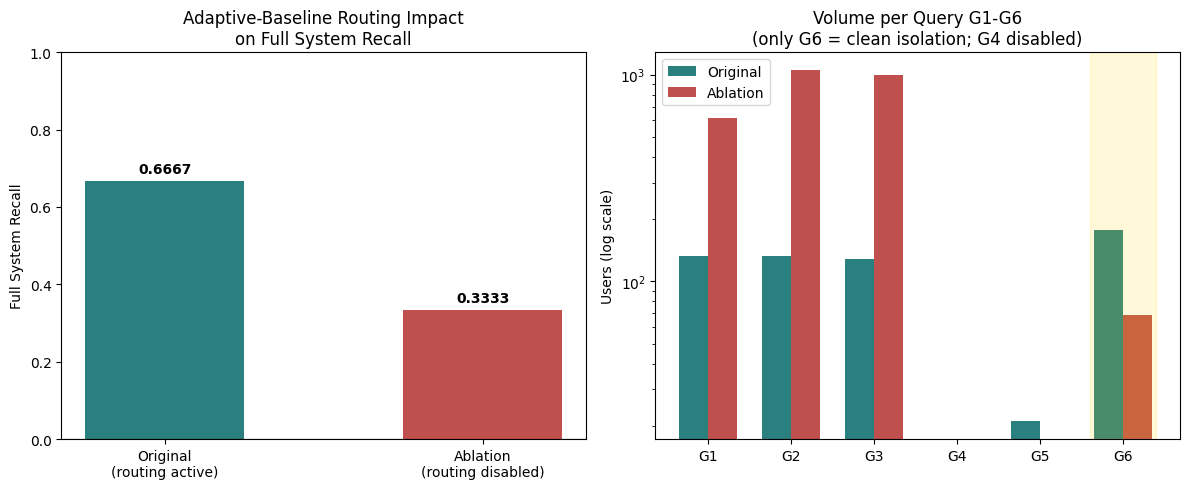

In [9]:
print("TABLE 1 -- Headline summary")
tabel1 = pd.DataFrame([
    {"Condition": "Original (routing active)", "Population": len(candidates_graph) + len(near_miss_group),
     "Graph_TP": h_graph_asli['TP'], "Graph_Recall": h_graph_asli['Recall'],
     "FullSystem_TP": h_full_asli['TP'], "FullSystem_Recall": h_full_asli['Recall']},
    {"Condition": "Ablation (routing disabled)", "Population": len(candidates_graph_ablasi),
     "Graph_TP": h_graph_ablasi['TP'], "Graph_Recall": h_graph_ablasi['Recall'],
     "FullSystem_TP": h_full_ablasi['TP'], "FullSystem_Recall": h_full_ablasi['Recall']},
])
print(tabel1)

print("\nTABLE 2 -- Per-actor status")
jalur_asli_map = {
    'ACM2278': 'L1 + G2', 'CMP2946': 'L1 only', 'MBG3183': 'L1 only',
    'PLJ1771': 'G6 only (relational)', 'CDE1846': 'G6 only (covariance-aligned evasion)',
    'HIS1706': '-- (FN, attributed via PLJ1771)',
}
rows_t2 = []
for aktor in sorted(MALICIOUS_USERS):
    l1_status = "YES" if aktor in l1_flagged else "NO"
    status_asli = "CAUGHT" if aktor in full_asli else "FALSE NEGATIVE"
    status_ablasi = "CAUGHT" if aktor in full_ablasi else "LOST" if aktor in full_asli else "FALSE NEGATIVE"
    bergantung = ("YES -- only path is G6 (routing)" if aktor in aktor_hilang
                  else "NO -- already caught via L1" if l1_status == "YES"
                  else "N/A -- not caught in either condition")
    rows_t2.append({"Actor": aktor, "L1_flagged": l1_status, "Original_path": jalur_asli_map.get(aktor, '?'),
                     "Status_Original": status_asli, "Status_Ablation": status_ablasi, "Depends_on_routing": bergantung})
tabel2 = pd.DataFrame(rows_t2)
print(tabel2)

print("\nTABLE 3 -- Volume per query (with isolation warning)")
g1_a=len(set(state04['g1_suspects_a'])); g2_a=len(set(state04['g2_suspects_a']))
g3_a=len(set(state04['g3_suspects_a'])); g5_a=len(set(state04['g5_suspects_a'])); g6_a=len(set(state04['g6_suspects_a']))
tabel3 = pd.DataFrame([
    {"Query": "G1", "Original": len(g1_suspects), "Ablation": g1_a, "Clean_isolation": "NO -- candidate population changes"},
    {"Query": "G2", "Original": len(g2_suspects), "Ablation": g2_a, "Clean_isolation": "NO -- candidate population changes"},
    {"Query": "G3", "Original": len(g3_suspects), "Ablation": g3_a, "Clean_isolation": "NO -- candidate population changes"},
    {"Query": "G5", "Original": len(g5_suspects), "Ablation": g5_a, "Clean_isolation": "N/A -- near-miss disabled by design"},
    {"Query": "G6", "Original": len(g6_suspects), "Ablation": g6_a, "Clean_isolation": "YES -- only cleanly isolated query"},
])
print(tabel3)
print("\nSample-size note: n=6 actors. Losing 2/6 is a mechanistic/illustrative finding, NOT a claim with statistical power.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
conditions = ['Original\n(routing active)', 'Ablation\n(routing disabled)']
recall_vals = [h_full_asli['Recall'], h_full_ablasi['Recall']]
bars = ax.bar(conditions, recall_vals, color=['#2a7f7f', '#c0504d'], width=0.5)
for bar, v in zip(bars, recall_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.4f}', ha='center', fontweight='bold')
ax.set_ylabel('Full System Recall'); ax.set_title('Adaptive-Baseline Routing Impact\non Full System Recall')
ax.set_ylim(0, 1.0); ax.axhline(0, color='black', linewidth=0.8)

ax2 = axes[1]
queries = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
asli_vals = [len(g1_suspects), len(g2_suspects), len(g3_suspects), 0, len(g5_suspects), len(g6_suspects)]
ablasi_vals = [g1_a, g2_a, g3_a, 0, g5_a, g6_a]
x = np.arange(len(queries)); w = 0.35
ax2.bar(x - w/2, asli_vals, w, label='Original', color='#2a7f7f')
ax2.bar(x + w/2, ablasi_vals, w, label='Ablation', color='#c0504d')
ax2.set_xticks(x); ax2.set_xticklabels(queries)
ax2.set_ylabel('Users (log scale)'); ax2.set_yscale('log')
ax2.set_title('Volume per Query G1-G6\n(only G6 = clean isolation; G4 disabled)')
ax2.legend(); ax2.axvspan(4.6, 5.4, color='gold', alpha=0.15)
plt.tight_layout()
plt.savefig('../results/figures/AWIK_Ablasi_Routing_Ringkasan.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
io.save_df(df_final, '05_df_final')
io.save_json({
    'h_l1': h_l1, 'h_gc': h_gc, 'h_full': h_full,
    'full_system': sorted(full_system),
    'h_full_asli': h_full_asli, 'h_full_ablasi': h_full_ablasi,
    'h_graph_asli': h_graph_asli, 'h_graph_ablasi': h_graph_ablasi,
    'aktor_hilang': aktor_hilang,
}, '05_evaluation_state')
print("Checkpoint saved -> data/interim/05_*")

Checkpoint saved -> data/interim/05_*
